# Scaling Method Comparison — After Yeo-Johnson Transform

Compares 3 scaling methods applied on top of Yeo-Johnson transformation.

**Features:** 12 continuous numeric features (binary features excluded)  
**Base transform:** Yeo-Johnson  
**Scalers:** StandardScaler, RobustScaler, MinMaxScaler

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer

import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

COLORS = {
    'Yeo-Johnson (no scaling)': '#8c8c8c',
    'YeoJohnson + StandardScaler': '#239DD9',
    'YeoJohnson + RobustScaler':   '#FF911E',
    'YeoJohnson + MinMaxScaler':   '#55a868',
}

print('Libraries loaded.')

Libraries loaded.


In [4]:
df = pd.read_csv('./datasets/phishing_url_features.csv')
print(f'Loaded: {len(df):,} rows x {df.shape[1]} columns')

CONTINUOUS_FEATURES = [
    'URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'PathDepth',
    'NoOfSubDomain', 'DigitRatioInURL', 'NoOfSpecialCharsInURL',
    'NoOfDots', 'NoOfDashInURL', 'DomainEntropy', 'NoOfQueryParams',
]

X = df[CONTINUOUS_FEATURES].copy()
print(f'Features: {len(CONTINUOUS_FEATURES)}')

Loaded: 5,183,050 rows x 29 columns
Features: 12


In [5]:
# ── Apply Yeo-Johnson base transform ──────────────────────────────────────
pt_yj = PowerTransformer(method='yeo-johnson')
X_yj  = pd.DataFrame(pt_yj.fit_transform(X), columns=CONTINUOUS_FEATURES)

# ── Apply scalers on top ───────────────────────────────────────────────────
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler(),
    'MinMaxScaler':   MinMaxScaler(),
}

results = {'Yeo-Johnson (no scaling)': X_yj}
for name, scaler in scalers.items():
    key = f'YeoJohnson + {name}'
    results[key] = pd.DataFrame(
        scaler.fit_transform(X_yj),
        columns=CONTINUOUS_FEATURES
    )

print('All combinations applied:')
for k in results: print(f'  {k}')

All combinations applied:
  Yeo-Johnson (no scaling)
  YeoJohnson + StandardScaler
  YeoJohnson + RobustScaler
  YeoJohnson + MinMaxScaler


In [6]:
# ── Summary table ──────────────────────────────────────────────────────────
rows = []
for method, data in results.items():
    rows.append({
        'Combination':  method,
        'Mean |Skew|':  data.skew().abs().mean().round(4),
        'Max |Skew|':   data.skew().abs().max().round(4),
        'Within ±0.5':  int((data.skew().abs() <= 0.5).sum()),
        'Mean':         data.mean().mean().round(4),
        'Std':          data.std().mean().round(4),
        'Range (avg)':  (data.max() - data.min()).mean().round(4),
    })

summary_df = pd.DataFrame(rows).set_index('Combination')
print('Summary:')
display(summary_df.style
    .highlight_max(subset=['Within ±0.5'], color='#239DD9')
    .highlight_min(subset=['Mean |Skew|', 'Max |Skew|'], color='#239DD9')
    .format('{:.4f}', subset=['Mean |Skew|', 'Max |Skew|', 'Mean', 'Std', 'Range (avg)'])
)

Summary:


,Mean |Skew|,Max |Skew|,Within ±0.5,Mean,Std,Range (avg)
Combination,,,,,,
Yeo-Johnson (no scaling),0.3582,1.7456,10,0.0000,1.0000,9.7652
YeoJohnson + StandardScaler,0.3582,1.7456,10,0.0000,1.0000,9.7652
YeoJohnson + RobustScaler,0.3582,1.7456,10,0.1024,0.7980,7.8988
YeoJohnson + MinMaxScaler,0.3582,1.7456,10,0.3517,0.1791,1.0000


## Chart 1 — Skewness After Each Combination

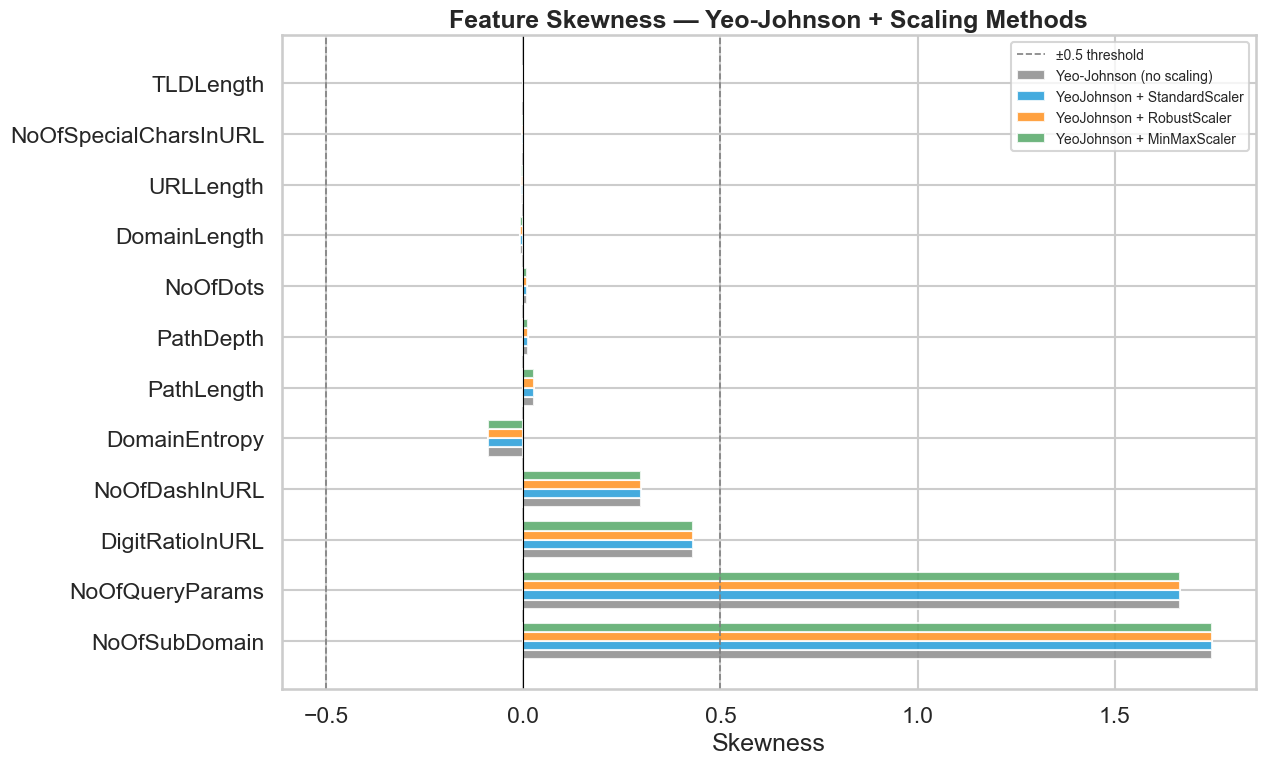

In [7]:
skew_df = pd.DataFrame({k: v.skew() for k, v in results.items()})
skew_df = skew_df.reindex(skew_df.abs().max(axis=1).sort_values(ascending=False).index)

n_methods  = len(results)
n_features = len(CONTINUOUS_FEATURES)
y      = np.arange(n_features)
height = 0.18

fig, ax = plt.subplots(figsize=(13, 8))
for i, method in enumerate(results):
    offset = (i - n_methods / 2) * height + height / 2
    ax.barh(y + offset, skew_df[method].values, height=height,
            color=COLORS[method], alpha=0.85, label=method)

ax.axvline(x= 0.5, color='grey', linestyle='--', linewidth=1.2, label='±0.5 threshold')
ax.axvline(x=-0.5, color='grey', linestyle='--', linewidth=1.2)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(skew_df.index)
ax.set_xlabel('Skewness')
ax.set_title('Feature Skewness — Yeo-Johnson + Scaling Methods', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Chart 2 — Outlier Sensitivity (feature range after scaling)

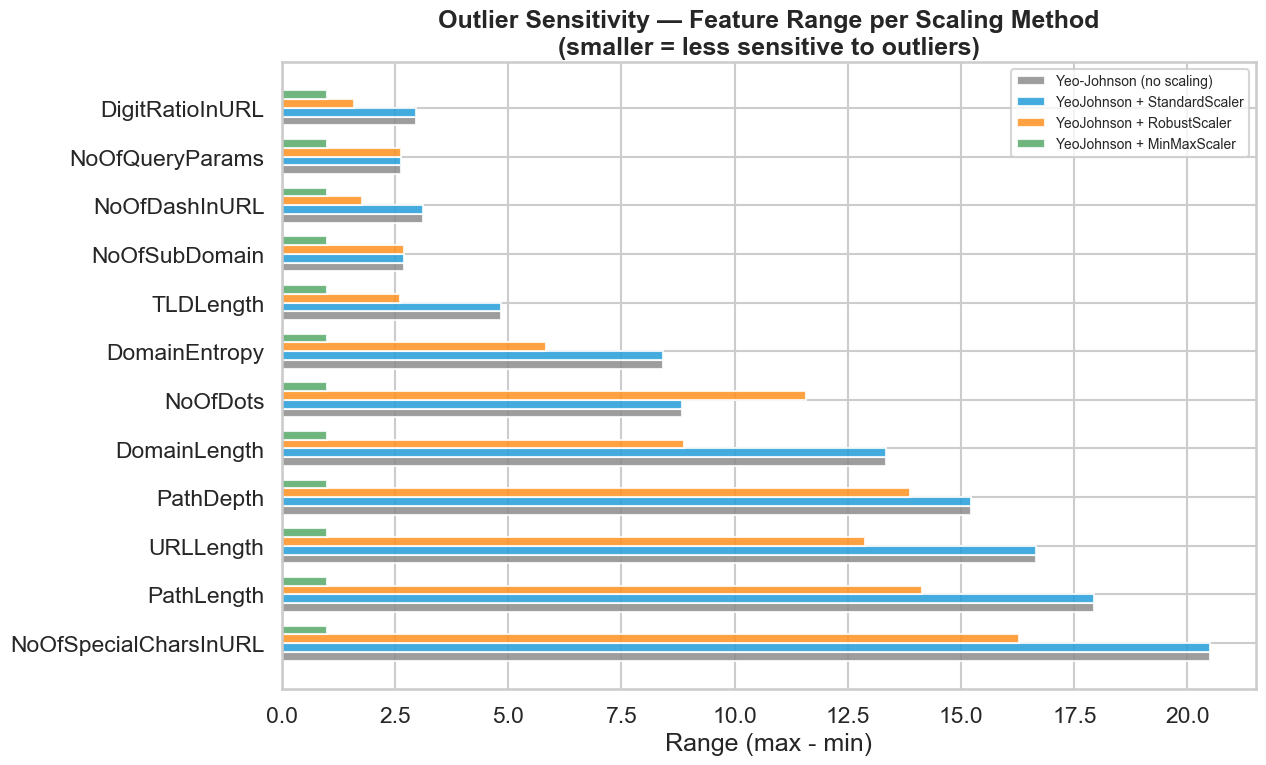

In [8]:
range_df = pd.DataFrame({k: v.max() - v.min() for k, v in results.items()})
range_df = range_df.reindex(range_df.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 8))
for i, method in enumerate(results):
    offset = (i - n_methods / 2) * height + height / 2
    ax.barh(y + offset, range_df[method].values, height=height,
            color=COLORS[method], alpha=0.85, label=method)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(range_df.index)
ax.set_xlabel('Range (max - min)')
ax.set_title('Outlier Sensitivity — Feature Range per Scaling Method\n(smaller = less sensitive to outliers)', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Chart 3 — Boxplots per Combination (subsampled)

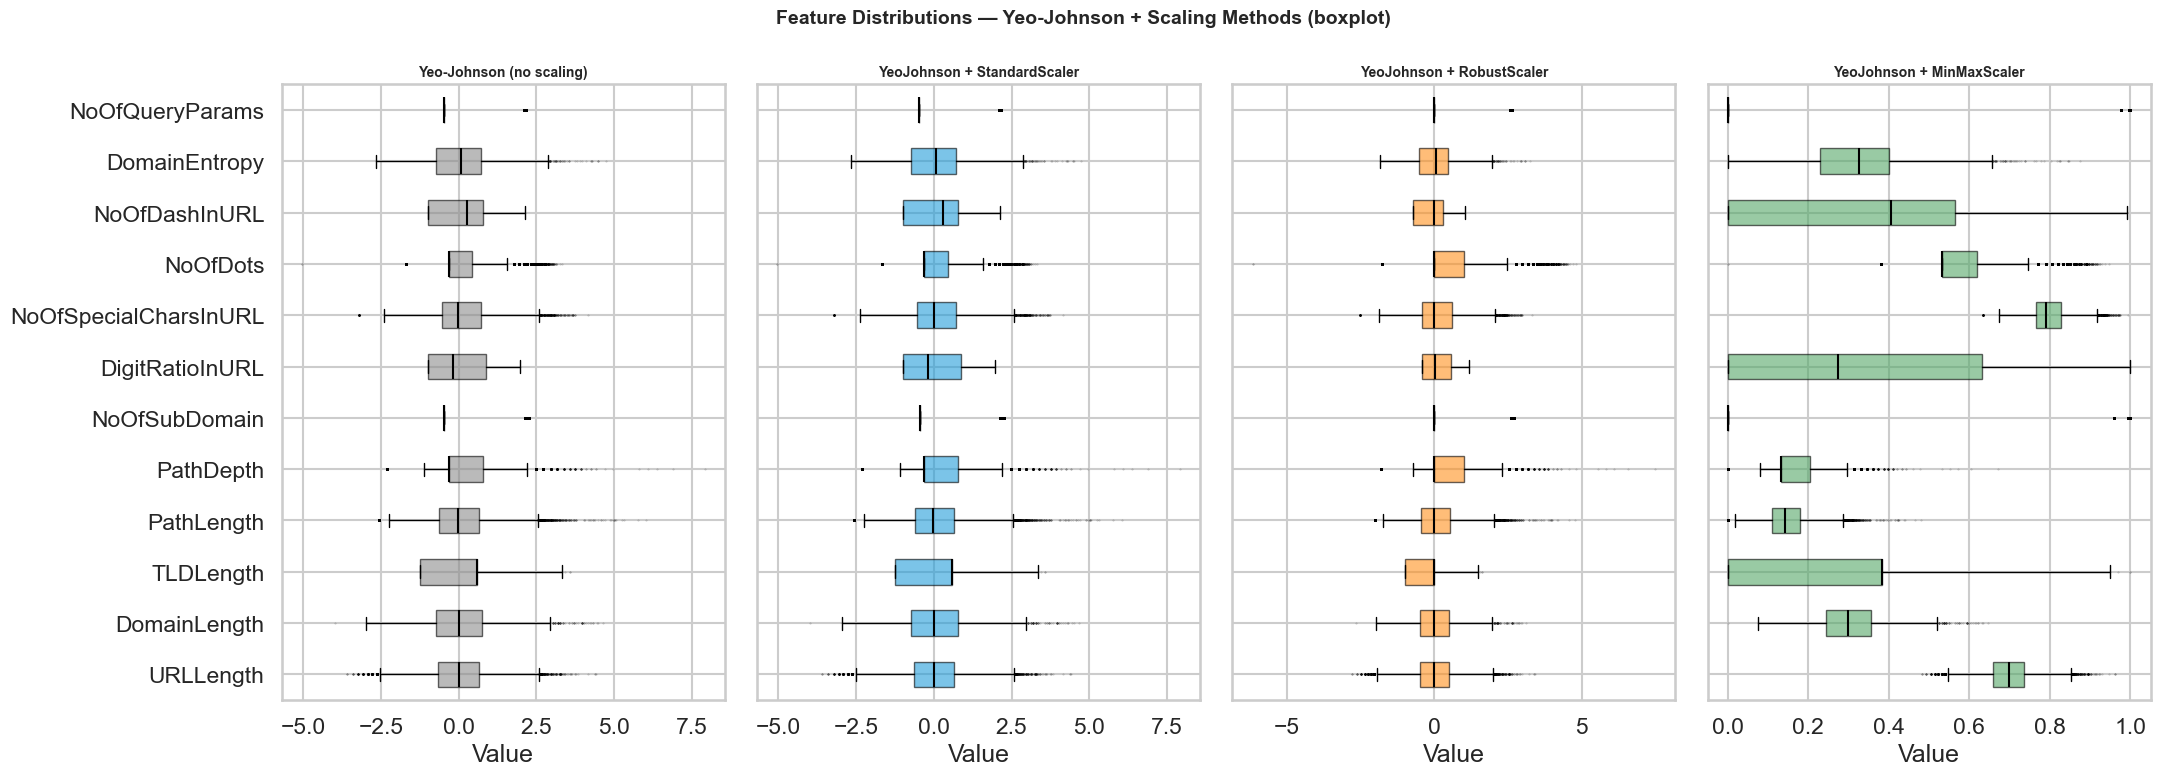

In [9]:
SAMPLE_N = 50_000
rng = np.random.RandomState(42)
idx = rng.choice(len(X), SAMPLE_N, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(22, 8))
for ax, (method, color) in zip(axes, COLORS.items()):
    sample = results[method].iloc[idx]
    ax.boxplot(
        [sample[col].values for col in CONTINUOUS_FEATURES],
        vert=False, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='.', markersize=1, alpha=0.2),
        widths=0.5,
    )
    ax.set_yticks(range(1, len(CONTINUOUS_FEATURES) + 1))
    ax.set_yticklabels(CONTINUOUS_FEATURES if ax == axes[0] else [])
    ax.set_title(method, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')

plt.suptitle('Feature Distributions — Yeo-Johnson + Scaling Methods (boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()